#### Decision Tree Algorithm- Is a supervised that can be used for both classification and Regression problems, but mostly it is preferred for solving Classification problems

##### In order to build a tree, We use CART algo (Classification and Regression Tree)

##### Binary splitting

#### Works on NON-LINEAR Model

###### Root Node: The topmost node of a decision tree where the splitting process starts.

###### Splitting: The process of dividing a node into two or more sub-nodes based on feature values.

###### Decision Node: An internal node that splits into further sub-nodes based on conditions.

###### Leaf Node: The terminal node of a decision tree that represents the final class label or output.
###### Pruning - The process of removing unnecessary branches or nodes from a decision tree to reduce complexity and avoid overfitting

##### Entropy/Gini Index- A measure of impurity.

###### E(S) = -(P+)log2(P+)-(P-)log2(P-)
###### p+ -> probability of yes, p- ->prob if NO


##### Information Gain-The reduction in entropy achieved after splitting a dataset on a particular feature
###### IG = E(S) - Weighted Entropy

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import plot_decision_regions

In [3]:
dataset = pd.read_csv("social_ads_generated.csv")
dataset.head(3)

,Age,Salary,Purchased
0,26,90083,1
1,42,113082,0
2,21,130449,0


##### First checking the nature of dataset Linear or Non Linear

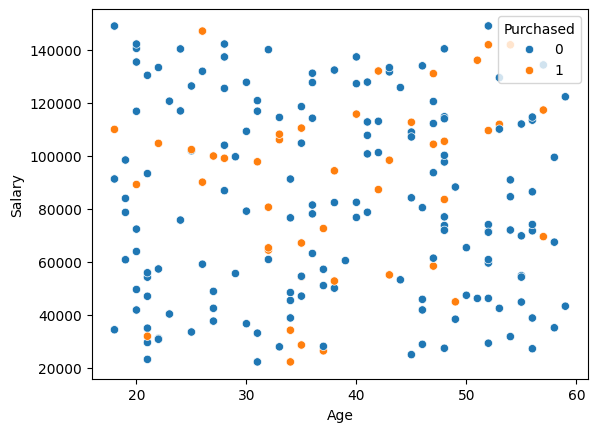

In [29]:
sns.scatterplot(data=dataset, x='Age', y='Salary', hue='Purchased')
plt.show()

In [10]:
x = dataset.iloc[:, :-1]
y = dataset["Purchased"]

In [ ]:
from sklearn.preprocessing import StandardScaler

In [13]:
sc = StandardScaler()
x_scaled =sc.fit_transform(x)

In [16]:
X_scaled_df = pd.DataFrame(x_scaled, columns=x.columns)

In [17]:
from sklearn.model_selection import train_test_split

In [18]:
x_train, x_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42)

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# We have used CART algorithm, Accodrding to Gini Index it is as default
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [26]:
# By using Entropy
dt1 = DecisionTreeClassifier(criterion='entropy')
dt1.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [27]:
dt1.score(x_test, y_test)

0.75

In [21]:
dt.score(x_test, y_test)

0.65

In [ ]:
# just for testing the model
dt.predict([[26,90083]])

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

c:\Users\sures\OneDrive\Desktop\python\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


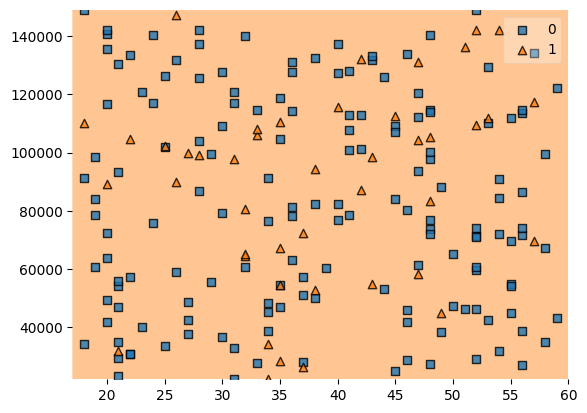

In [ ]:
# Non Linear Data seeiing by the decision boundary
plot_decision_regions(x.to_numpy(),y.to_numpy(),clf =dt)
plt.show()

In [23]:
from sklearn.tree import plot_tree

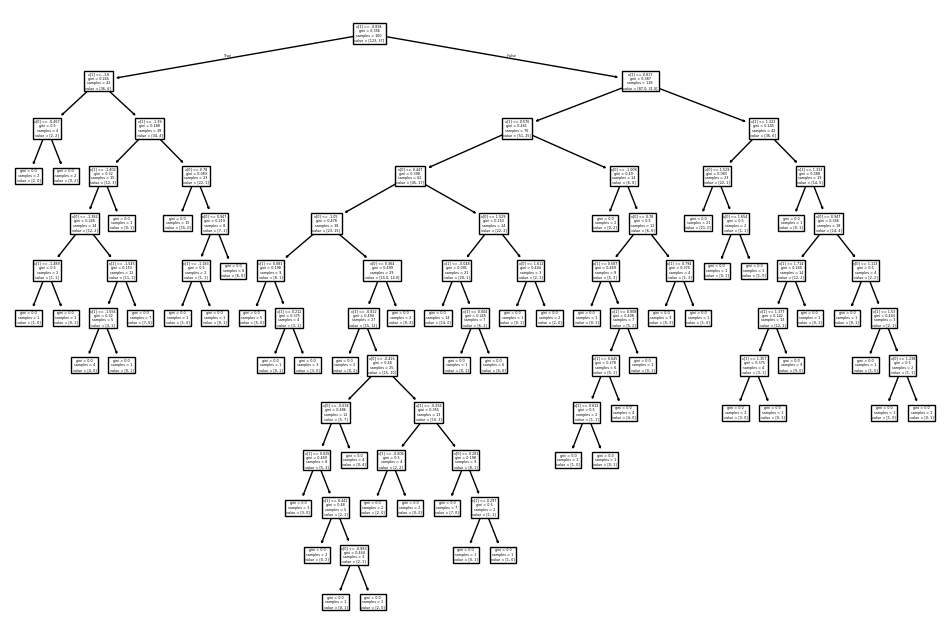

In [25]:
plt.figure(figsize=(12,8))
plot_tree(dt)
plt.show()